#FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving exchange_rate.csv to exchange_rate.csv


Load Dataset

In [3]:
df = pd.read_csv('exchange_rate.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7588, 2)

First 5 Rows:


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849



Column Names:
Index(['date', 'Ex_rate'], dtype='object')

Data Types:
date        object
Ex_rate    float64
dtype: object


Data Preparation

In [4]:
# Convert date column into datetime format

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Sort data by date
df = df.sort_values('date')

# Set date as index
df = df.set_index('date')

print(df.head())
print("\nDate Range:")
print(df.index.min(), "to", df.index.max())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849

Date Range:
1990-01-01 00:00:00 to 2010-10-10 00:00:00


Check Missing Values & Duplicates

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Dates:")
print(df.index.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Missing Values:
Ex_rate    0
dtype: int64

Duplicate Dates:
0

Statistical Summary:


,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


Part 1 - Initial Exploration

Time Series Plot

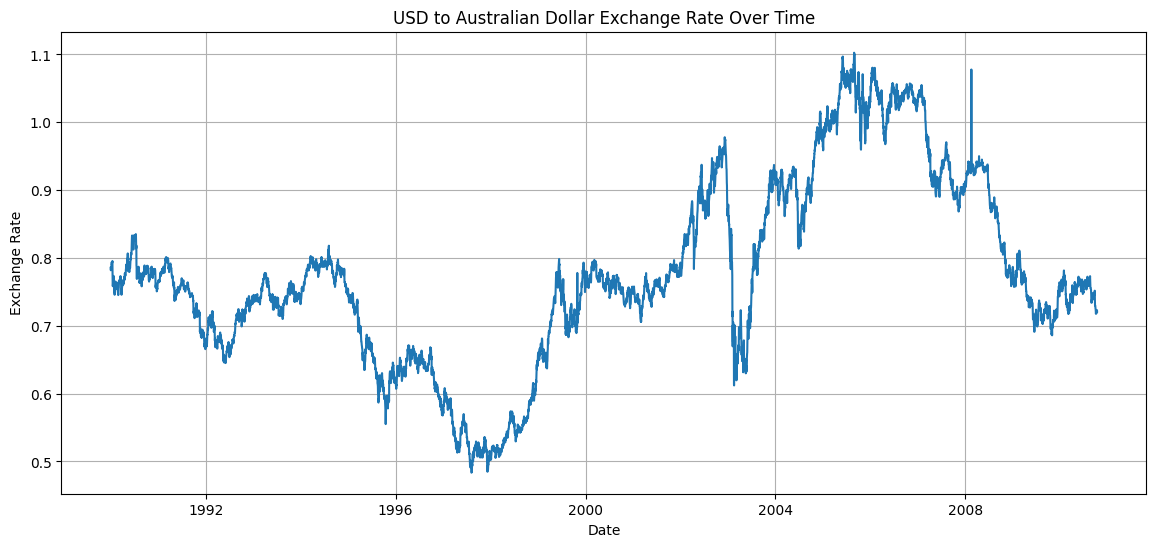

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df['Ex_rate'])

plt.title('USD to Australian Dollar Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)

plt.show()

Anomaly / Outlier Check

In [7]:
Q1 = df['Ex_rate'].quantile(0.25)
Q3 = df['Ex_rate'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Ex_rate'] < lower_bound) |
    (df['Ex_rate'] > upper_bound)
]

print("Number of potential outliers:", len(outliers))
display(outliers.head())

Number of potential outliers: 0


,Ex_rate
date,


Part 2 - ARIMA Model

Train-Test Split

In [8]:
# Use 80% data for training and 20% for testing

split_point = int(len(df) * 0.80)

train = df['Ex_rate'].iloc[:split_point]
test = df['Ex_rate'].iloc[split_point:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

print("\nTraining Period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting Period:")
print(test.index.min(), "to", test.index.max())

Training Data: 6070
Testing Data: 1518

Training Period:
1990-01-01 00:00:00 to 2006-08-14 00:00:00

Testing Period:
2006-08-15 00:00:00 to 2010-10-10 00:00:00


Stationary Test

In [9]:
result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("The series is stationary.")
else:
    print("The series is non-stationary and differencing is required.")

ADF Statistic: -0.9808550190078997
p-value: 0.7601827946372031
The series is non-stationary and differencing is required.


Differencing + ACF/PACF

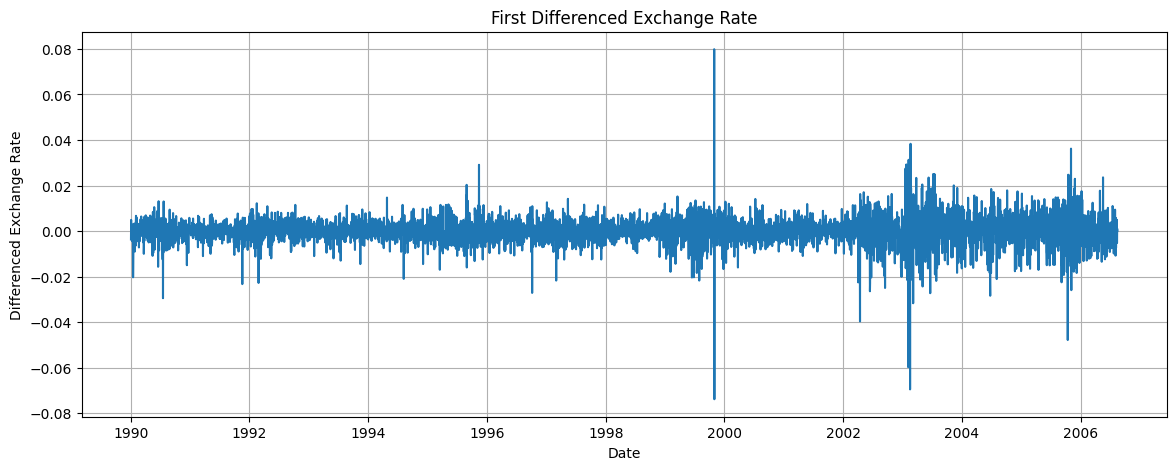

In [10]:
# First difference
diff_train = train.diff().dropna()

plt.figure(figsize=(14, 5))
plt.plot(diff_train)
plt.title('First Differenced Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Differenced Exchange Rate')
plt.grid(True)
plt.show()

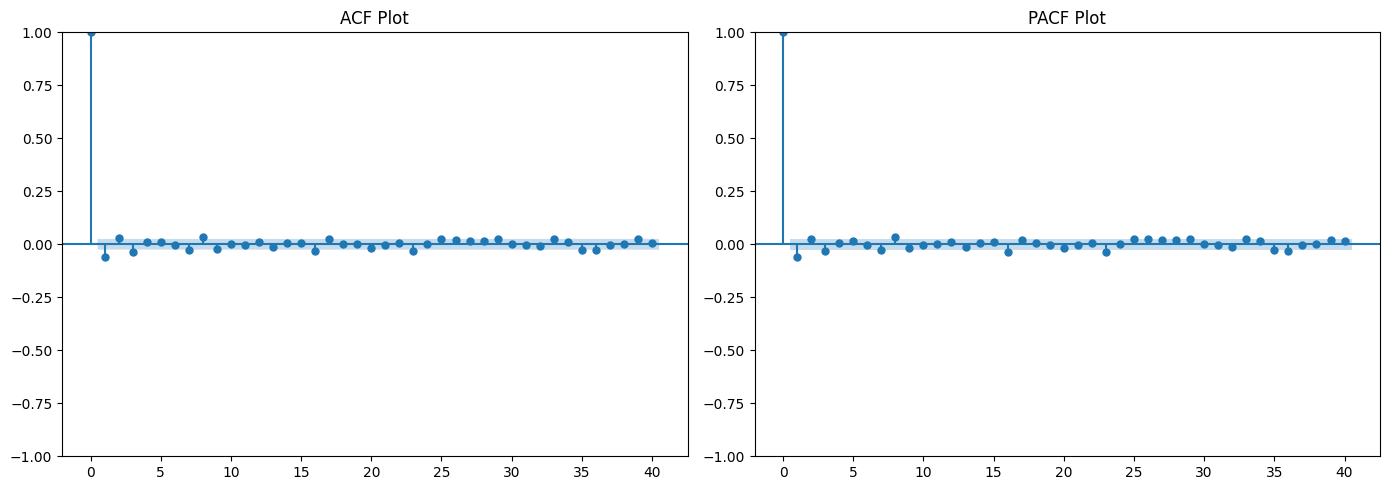

In [11]:
# ACF and PACF plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(diff_train, lags=40, ax=axes[0])
axes[0].set_title('ACF Plot')

plot_pacf(diff_train, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF Plot')

plt.tight_layout()
plt.show()

ARIMA Parameter Selection using AIC

In [12]:
# Search for the best ARIMA parameters using AIC

aic_results = []

for p in range(4):
    for d in [1]:
        for q in range(4):

            try:
                model = ARIMA(
                    train,
                    order=(p, d, q),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fitted_model = model.fit()

                aic_results.append({
                    'p': p,
                    'd': d,
                    'q': q,
                    'AIC': fitted_model.aic
                })

            except:
                pass

aic_df = pd.DataFrame(aic_results)
aic_df = aic_df.sort_values('AIC')

display(aic_df.head(10))

,p,d,q,AIC
4,1,1,0,-45417.889968
5,1,1,1,-45415.993462
9,2,1,1,-45412.736943
8,2,1,0,-45411.762224
1,0,1,1,-45409.056997
12,3,1,0,-45407.312919
6,1,1,2,-45405.266017
13,3,1,1,-45405.218106
14,3,1,2,-45405.058658
10,2,1,2,-45403.811588


Fit ARIMA Model

In [13]:
arima_model = ARIMA(
    train,
    order=(1, 1, 0)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 0)   Log Likelihood               22714.978
Date:                Mon, 17 Aug 2026   AIC                         -45425.957
Time:                        09:21:17   BIC                         -45412.535
Sample:                    01-01-1990   HQIC                        -45421.298
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0597      0.005    -11.760      0.000      -0.070      -0.050
sigma2      3.285e-05   1.85e-07    177.956      0.000    3.25e-05    3.32e-05
Ljung-Box (L1) (Q):                   0.01   Jarque-

ARIMA Residual Diagnostics

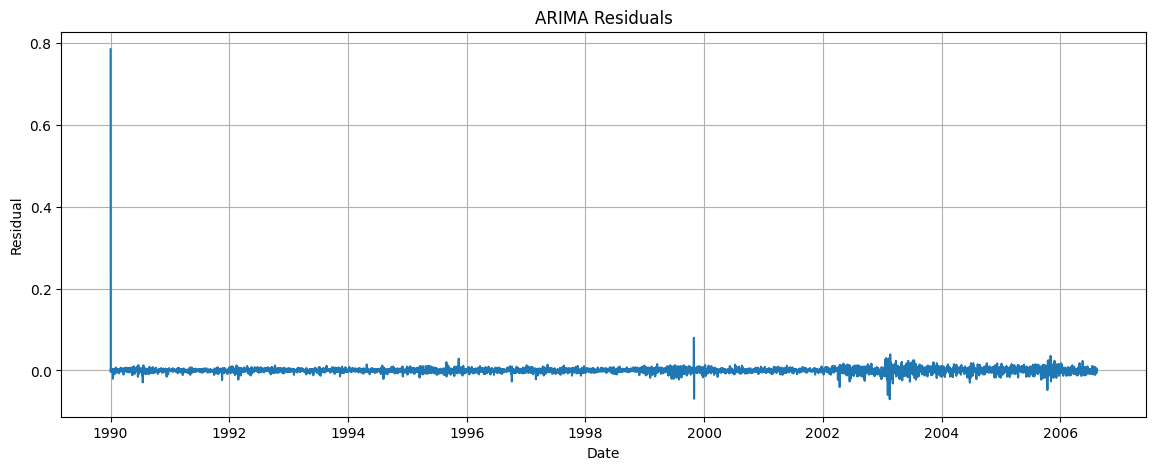

In [14]:
residuals = arima_fit.resid

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title('ARIMA Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

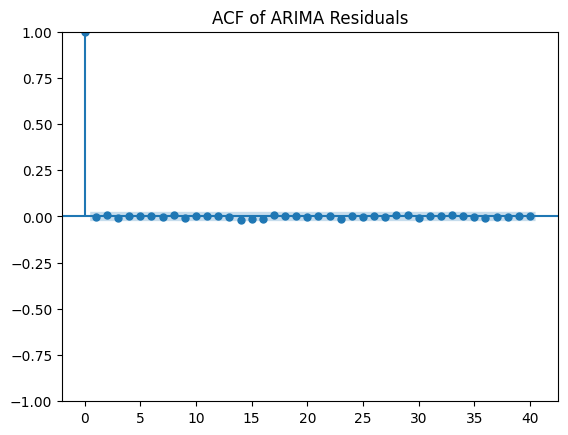

In [15]:
# Residual ACF

plt.figure(figsize=(10, 5))
plot_acf(residuals.dropna(), lags=40)
plt.title('ACF of ARIMA Residuals')
plt.show()

In [16]:
# Ljung-Box test

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20],
    return_df=True
)

display(ljung_box)

,lb_stat,lb_pvalue
10,2.489562,0.991027
20,6.849947,0.997149


ARIMA Forecast

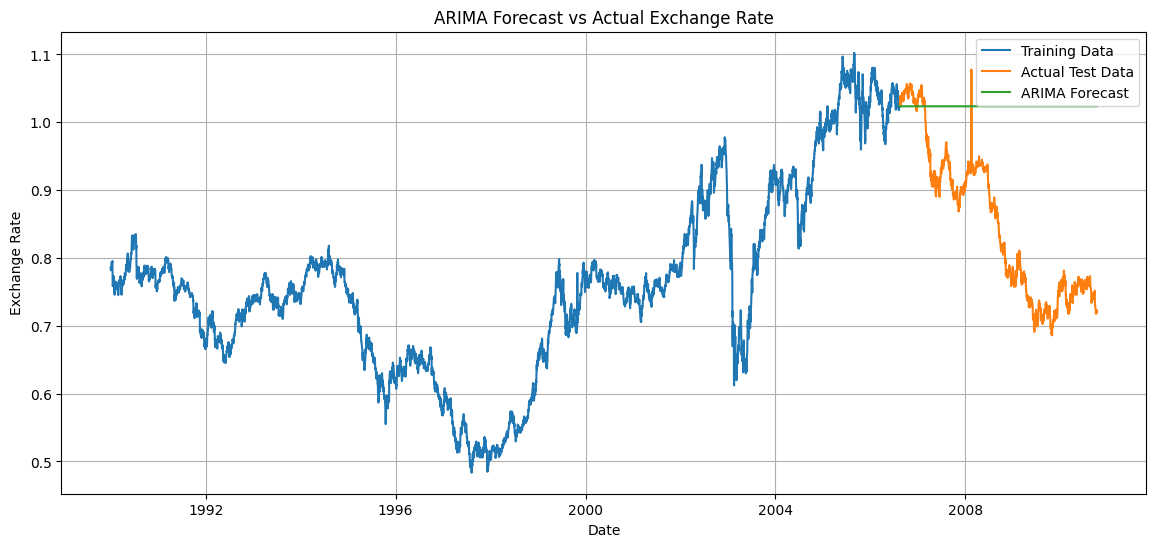

In [17]:
# Forecast the testing period

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')

plt.title('ARIMA Forecast vs Actual Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

Part 3 - Exponential Smoothing

Simple Exponential Smoothing

In [18]:
ses_model = SimpleExpSmoothing(
    train,
    initialization_method='estimated'
)

ses_fit = ses_model.fit(
    optimized=True
)

print(ses_fit.summary())
print("\nOptimized Smoothing Level:",
      ses_fit.params['smoothing_level'])

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:             SimpleExpSmoothing   SSE                              0.199
Optimized:                       True   AIC                         -62659.343
Trend:                           None   BIC                         -62645.921
Seasonal:                        None   AICC                        -62659.337
Seasonal Periods:                None   Date:                 Mon, 17 Aug 2026
Box-Cox:                        False   Time:                         09:24:18
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9429396                alpha                 True
initial_level              0.7853067                

SES Forecast

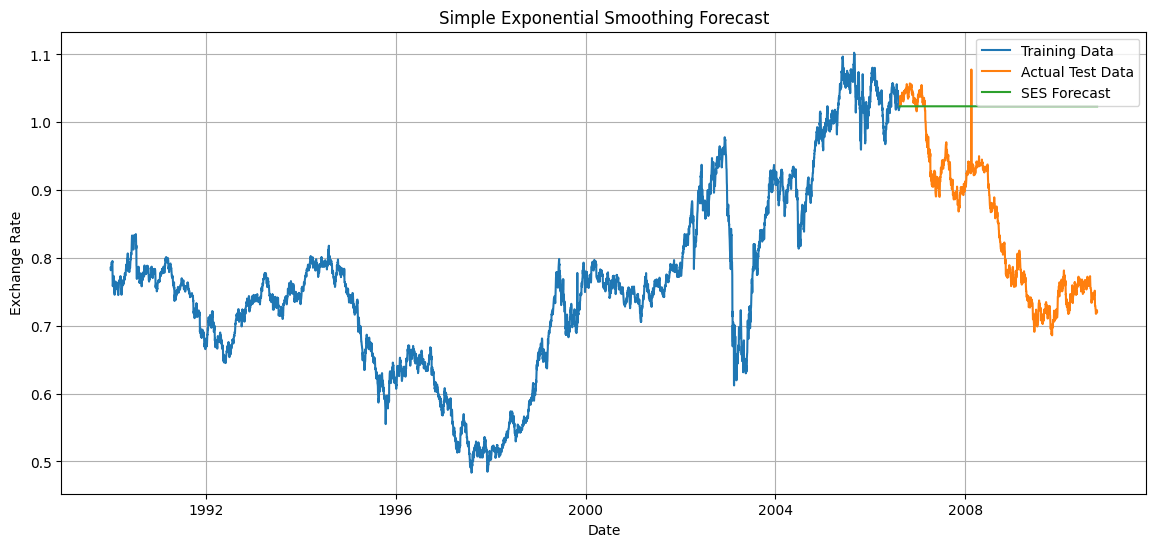

In [19]:
ses_forecast = ses_fit.forecast(
    steps=len(test)
)

plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, ses_forecast, label='SES Forecast')

plt.title('Simple Exponential Smoothing Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

Part 4 - Model Evaluation

Error Metrics

In [20]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    return mae, rmse, mape


arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

ses_mae, ses_rmse, ses_mape = calculate_metrics(
    test,
    ses_forecast
)

results = pd.DataFrame({
    'Model': ['ARIMA(1,1,0)', 'Simple Exponential Smoothing'],
    'MAE': [arima_mae, ses_mae],
    'RMSE': [arima_rmse, ses_rmse],
    'MAPE (%)': [arima_mape, ses_mape]
})

display(results)

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1,1,0)",0.177640,0.205359,22.789105
1,Simple Exponential Smoothing,0.177638,0.205356,22.788856


Final Model Comparison Plot

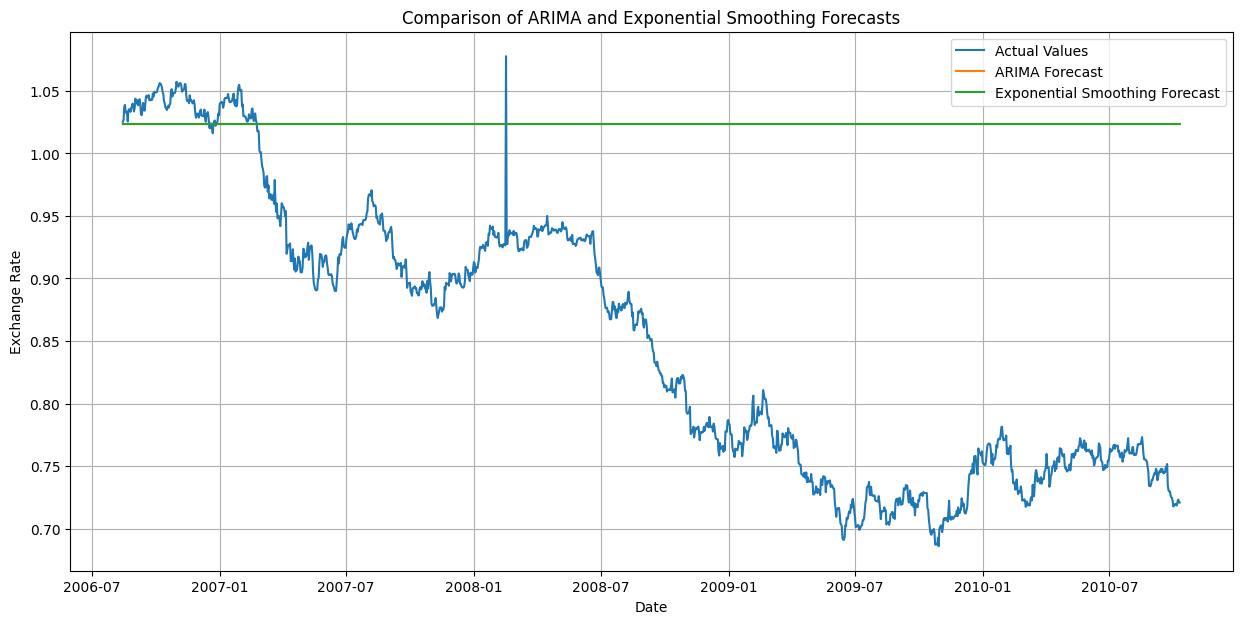

In [21]:
plt.figure(figsize=(15, 7))

plt.plot(test.index, test,
         label='Actual Values')

plt.plot(test.index, arima_forecast,
         label='ARIMA Forecast')

plt.plot(test.index, ses_forecast,
         label='Exponential Smoothing Forecast')

plt.title('Comparison of ARIMA and Exponential Smoothing Forecasts')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

Best Model

In [22]:
best_model = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

print("Best Performing Model based on RMSE:", best_model)

Best Performing Model based on RMSE: Simple Exponential Smoothing


Conclusion

The time series forecasting analysis was successfully performed on the USD to Australian Dollar exchange rate dataset using ARIMA and Simple Exponential Smoothing techniques. The data was cleaned, explored, and checked for missing values and anomalies before model building. ARIMA parameters were selected using stationarity analysis, ACF/PACF plots, and AIC.

Both models were evaluated using MAE, RMSE, and MAPE. The model with the lower error values is considered the better forecasting model for this dataset. Overall, the analysis demonstrates that time series techniques can be effectively used to understand historical exchange-rate patterns and forecast future exchange rates.